<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/healthcare/G5_EGG_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sklearn
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.model_selection import GridSearchCV


In [4]:
drive.flush_and_unmount()
drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/Healthcare/EGG")

Mounted at /content/drive


In [5]:
df = pd.read_excel('EEG-data.xlsx')

In [7]:
df.head(10)

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X4086,X4087,X4088,X4089,X4090,X4091,X4092,X4093,X4094,y
0,0,-56,-50,-64,-91,-135,-140,-134,-114,-115,...,-37,-43,-63,-82,-114,-138,-159,-172,-180,5
1,1,14,25,31,36,33,33,27,27,21,...,-45,-32,-6,-7,-2,-20,-34,-40,-40,5
2,2,-159,-176,-174,-145,-101,-45,0,29,15,...,-40,-25,14,56,73,48,-12,-62,-100,4
3,3,34,31,29,19,16,12,3,-1,-5,...,-34,-33,-29,-22,-18,-14,-10,-9,0,3
4,4,44,50,46,43,43,46,45,40,36,...,4,5,6,6,2,1,0,-1,-4,2
5,5,142,262,382,451,452,435,544,562,462,...,164,-2,-118,-223,-304,-350,-339,-299,-253,1
6,6,-64,-72,-52,-24,4,21,18,-16,-53,...,-90,-85,-66,-42,-26,-10,-1,-12,-16,5
7,7,-55,-48,-48,-38,-23,0,11,22,21,...,51,61,64,42,-1,-53,-79,-93,-95,4
8,8,18,14,13,9,-6,-20,-31,-27,-10,...,-17,-3,9,25,49,63,82,96,102,4
9,9,50,48,45,41,47,51,53,40,37,...,-16,-30,-47,-63,-63,-50,-39,-25,-19,3


## Building and training an optimize model

In [251]:

def plot_confusion_matrix(confusion_matrix=None):
  """
  Plot confusion matrix in horizontal format.
  Works with:
  - A single 2D numpy array
  - A dictionary of multiple confusion matrices (e.g., from multiple models)
  """
  if isinstance(confusion_matrix, np.ndarray):
    confusion_matrix = {'Model': [confusion_matrix]}

  fig, axes = plt.subplots(1, len(confusion_matrix), figsize=(12,3))

  if len(confusion_matrix) == 1:
    axes = [axes] # <-- Make sure axes is iterable if 1D array passed

  for ax, (name, matrices) in zip(axes, confusion_matrix.items()):

      avg_cm = np.mean(matrices, axis=0)

      ax.imshow(avg_cm)
      ax.set_title(name)
      ax.set_xlabel("Predicted")
      ax.set_ylabel("Actual")

      for i in range(matrices[0].shape[0]):
          for j in range(matrices[0].shape[0]):
              ax.text(j, i, round(avg_cm[i,j],1), ha="center")

  plt.tight_layout()
  plt.show()

In [198]:
def outliers_middleware(threshold=None, include_outlier=False):
  if include_outlier == False and (threshold is None or threshold <= 0):
    raise ValueError("threshold must be greater than 0")

In [200]:
def prepare_dataset(dataset, threshold=None, include_outlier=False):
  """
  Clean up the dataset for the features and attributes & normalize the dataset using z-transform
  """
  outliers_middleware(threshold, include_outlier) # handling threshold error
  features_columns = dataset.columns.drop(['Unnamed: 0','y'], errors='ignore')
  X = dataset[features_columns]
  mean = np.mean(X)
  std = np.std(X)
  X = (X-mean)/std # <-- z-transform normalization
  y = dataset.get('y') if 'y' in dataset.columns else dataset.get('Y')
  if not include_outlier:
    mask = np.all((X<threshold) & (X>-threshold), axis=1)
    X_clean = X[mask]
    y_clean = y[mask]
    return X_clean, y_clean
  else:
    return X, y

In [235]:
def validate_model(model=None, X_test=None, y_test=None):
  """
  This method validate the modeld and return
  - `accuracy, y_pred, y_prob, cm`
  """
  y_pred = model.predict(X_test)
  if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_test)
  else:
      y_prob = None
  # 2. 3 → accuracy1
  accuracy = np.sum(y_pred == y_test)/len(y_test)
  cm = confusion_matrix(y_test, y_pred)
  return accuracy, y_pred, y_prob, cm

In [238]:
# training multy layer classier
def train_classifier_model(iteration=5, X_train=None, X_test=None, y_train=None, y_test=None, models=None, param_grids=None):
  """
  Training multi model classifier
  """
  accuracy_times = {name: [] for name in models }
  trained_model = {name: None for name in models }
  con_matrix = {name: [] for name in models }

  # Training iteration
  for ntimes in range(iteration):
     # 2.1 Train SVM on first half
    for name, model in models.items():
      if param_grids:
        # add grid search
        grid = GridSearchCV(model,
                            param_grid=param_grids[name],
                            cv=3)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        # validate on the best performed grid search model
        accuracy, y_pred, _, cm = validate_model(best_model, X_test, y_test)

        # 5. Append accuracy to accuracy_times
        accuracy_times[name].append(accuracy)
        trained_model[name] = model
        con_matrix[name].append(cm)

      else:
        model.fit(X_train, y_train)
        # validate model on test dataset
        accuracy, y_pred, _, cm = validate_model(model, X_test, y_test)

        # 5. Append accuracy to accuracy_times
        accuracy_times[name].append(accuracy)
        trained_model[name] = model
        con_matrix[name].append(cm)
  return accuracy_times, trained_model, con_matrix

In [202]:
def cross_validation_classifier(X=None, y=None, n_splits=5, models=None, random_state=None, iteration = 1, param_grids=None):
  """
  This method will prepare the dataste for k-fold(n_splits) cross validation
  And train all the models in the same dataset
  """
  kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
  accuracy = {name: [] for name in models}
  cm= {name: [] for name in models} # confusion matrix
  trained_model = {name: None for name in models }

  for train_idx, test_idx in kf.split(X):
      x_train = X.iloc[train_idx]
      x_test = X.iloc[test_idx]
      y_train = y.iloc[train_idx]
      y_test = y.iloc[test_idx]
      accuracy_times, _, con_matrix = train_classifier_model(iteration=iteration,
                                                             X_train=x_train,
                                                             X_test=x_test,
                                                             y_train=y_train,
                                                             y_test=y_test,
                                                             models=models,
                                                             param_grids=param_grids)
      for name, model in models.items():
        accuracy[name].extend(accuracy_times[name])
        cm[name].extend(con_matrix[name])
        trained_model[name] = model

  return accuracy, cm

In [203]:
# Create the model accuracy table
def create_accuracy_table (accuracy=None, iteration = 1, random_state = None, include_outlier = False, threshold = None):
  table = []
  for name, accuracy_result in accuracy.items():
    means = np.mean(accuracy_result)
    stds = np.std(accuracy_result)
    table.append([name, means, stds, iteration, random_state, include_outlier, threshold])
  table = pd.DataFrame(table, columns=['kernal', 'mean', 'std', 'iteration', 'seed','include_outlier', 'threshold'])
  return table

In [254]:
# Train SVM models for dataset including outliers
def classifier_models(iteration = 1, random_state = None, include_outlier = False, threshold = None, param_grids = None):
  """
  This function will create `4 classifier model`:
  - prepare the feature and classifier attributes
  - prepare the training & testing dataset
  * if `include_outlier = True` the threshold will not applied
  * if `iclude_outlier = False` then threshold must be provided
  - return an accuracy table on each iteration, and trained models for forther validation
  """
  outliers_middleware(threshold, include_outlier) # handling threshold error

  # list of the models to perform
  models = {
        'svm_lin': SVC(kernel='linear', C=1.0, random_state=random_state, decision_function_shape='ovo', probability=True),
        'svm_rbf': SVC(kernel='rbf', C=1.0, random_state=random_state, decision_function_shape='ovo'),
        'tree': DecisionTreeClassifier(criterion='gini', max_depth=20, random_state=random_state),
        'knn': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
        # 'cv': cross_validate()
    }
  # Prepare the dataset
  X_clean, y_clean = prepare_dataset(df, threshold=threshold, include_outlier=include_outlier)

  # Get the training and testing dataset
  X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean,
                                                        test_size=0.2,
                                                        random_state=random_state,
                                                        shuffle=True)

  # train the classifier model
  accuracy, trained_models, cm = train_classifier_model(iteration, X_train, X_test, y_train, y_test, models)

  # Train the classifier model on cross validation
  cv_accuracy, cv_cm = cross_validation_classifier(X_clean, y_clean, n_splits=5,
                                            models=models, random_state=random_state,
                                            param_grids = param_grids)

  # create accuracy table
  table = create_accuracy_table(accuracy=accuracy, iteration=iteration,
                                random_state=random_state,
                                include_outlier=include_outlier,
                                threshold=threshold)
  # Create accuracy table for Cross validation accuracy
  cv_table = create_accuracy_table(accuracy=cv_accuracy, iteration=iteration,
                                random_state=random_state,
                                include_outlier=include_outlier,
                                threshold=threshold)
  return accuracy, trained_models, table, cv_accuracy, cv_table, cm, cv_cm

**Calssify models iteration**
- grid param
- Include outliers or not
- Iteration
- Seed
- Threshold

In [255]:

param_grids = {
    'svm_lin': {'C':[0.1,1,10]},
    'svm_rbf': {'C':[0.1,1,10], 'gamma':[1,0.1,0.01]},
    'tree': {'max_depth':[5,10,20]},
    'knn': {'n_neighbors':[3,5,7]}
}

iteration = 2
random_state = None
include_outlier = True
threshold = None
accuracy, trained_models, table, cv_accuracy, cv_table, cm, cv_cm = classifier_models(iteration,
                                                                           random_state,
                                                                           include_outlier,
                                                                           threshold,
                                                                           param_grids = None)
print("----------------- SVM models accuracy table ---------------")
table

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


----------------- SVM models accuracy table ---------------


,kernal,mean,std,iteration,seed,include_outlier,threshold
0,svm_lin,0.630,0.000,2,None,True,None
1,svm_rbf,0.460,0.000,2,None,True,None
2,tree,0.415,0.005,2,None,True,None
3,knn,0.280,0.000,2,None,True,None


In [256]:
print("------- SVM models accuracy table On K-fold Cross Validation method  ----------")
cv_table

------- SVM models accuracy table On K-fold Cross Validation method  ----------


,kernal,mean,std,iteration,seed,include_outlier,threshold
0,svm_lin,0.562,0.039699,2,None,True,None
1,svm_rbf,0.504,0.066813,2,None,True,None
2,tree,0.374,0.050040,2,None,True,None
3,knn,0.298,0.031241,2,None,True,None


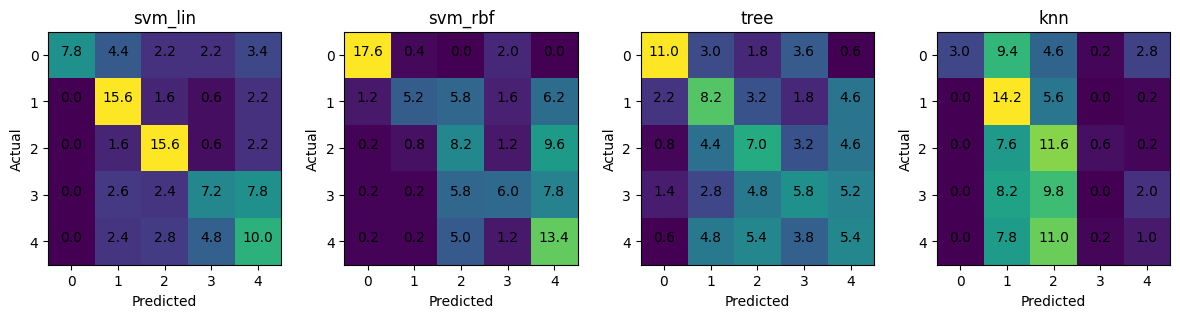

In [257]:
plot_confusion_matrix(cv_cm)

## Validating a model

In [258]:
X_clean, y_clean = prepare_dataset(df, threshold=None, include_outlier=True)

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean,
                                                        test_size=0.2,
                                                        random_state=42,
                                                        shuffle=True)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [265]:
accuracy, y_pred, y_prob, cm = validate_model(trained_models['svm_rbf'], X_test=X_test, y_test=y_test)

In [266]:
accuracy, y_pred, y_prob, cm

(np.float64(0.67),
 array([4, 2, 4, 5, 1, 2, 3, 1, 1, 3, 3, 1, 5, 1, 2, 5, 1, 5, 5, 5, 3, 4,
        1, 5, 4, 4, 4, 3, 5, 5, 5, 5, 3, 4, 4, 3, 2, 5, 1, 4, 1, 2, 5, 5,
        5, 3, 4, 2, 3, 3, 5, 3, 4, 5, 3, 5, 2, 5, 1, 2, 1, 3, 3, 2, 1, 1,
        2, 4, 5, 5, 5, 2, 5, 5, 3, 1, 5, 1, 5, 5, 1, 3, 4, 5, 5, 5, 5, 1,
        5, 5, 4, 3, 3, 1, 5, 3, 4, 5, 4, 5]),
 None,
 array([[17,  1,  0,  1,  0],
        [ 0,  8,  2,  1,  6],
        [ 0,  1, 13,  1,  5],
        [ 0,  1,  1, 12,  8],
        [ 1,  0,  3,  1, 17]]))

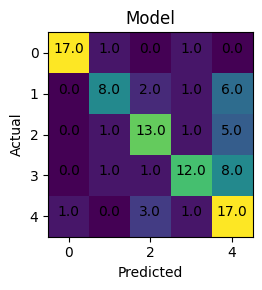

In [267]:
plot_confusion_matrix(cm)